# Association Mining Comparison (Apriori, FP-Growth, ECLAT)

This notebook runs the three association-mining techniques on the same mushroom transactions and compares their outputs.

## Blocks
1. Imports and availability checks
2. Load/clean data and create transactions
3. Apriori
4. FP-Growth
5. ECLAT
6. Side-by-side comparison

In [4]:
from pathlib import Path
import importlib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

HAS_APYORI = importlib.util.find_spec('apyori') is not None
HAS_PYFPGROWTH = importlib.util.find_spec('pyfpgrowth') is not None
HAS_PYECLAT = importlib.util.find_spec('pyECLAT') is not None

if HAS_APYORI:
    from apyori import apriori
if HAS_PYFPGROWTH:
    import pyfpgrowth
if HAS_PYECLAT:
    from pyECLAT import ECLAT

print('Apriori:', HAS_APYORI, '| FP-Growth:', HAS_PYFPGROWTH, '| ECLAT:', HAS_PYECLAT)

Apriori: True | FP-Growth: True | ECLAT: True


In [5]:
def resolve_dataset_path():
    candidates = [
        Path.cwd().parent.parent / 'Mushroom Dataset' / 'mushrooms 2.csv',
        Path.cwd().parent / 'Mushroom Dataset' / 'mushrooms 2.csv',
        Path.cwd() / 'Mushroom Dataset' / 'mushrooms 2.csv',
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError('Cannot find Mushroom Dataset/mushrooms 2.csv from current location.')

def load_clean_transactions(rare_threshold=0.01):
    df = pd.read_csv(resolve_dataset_path())
    df = df.replace('?', np.nan).drop_duplicates().copy()

    for c in df.columns:
        if df[c].isna().any():
            mode_vals = df[c].mode(dropna=True)
            df[c] = df[c].fillna(mode_vals.iloc[0] if not mode_vals.empty else 'missing')

    min_count = max(1, int(rare_threshold * len(df)))
    outlier_mask = pd.Series(False, index=df.index)
    for c in df.columns:
        if c == 'class':
            continue
        vc = df[c].value_counts(dropna=False)
        rare_vals = vc[vc < min_count].index
        outlier_mask = outlier_mask | df[c].isin(rare_vals)

    df = df[~outlier_mask].copy()
    transactions = df.astype(str).apply(lambda r: [f'{c}={v}' for c, v in r.items()], axis=1).tolist()
    return df, transactions

df, transactions = load_clean_transactions()

# Runtime controls for faster mining on large transaction sets.
MAX_TRANSACTIONS = 3000
MIN_SUPPORT = 0.3
MIN_CONFIDENCE = 0.8
MAX_RULE_LENGTH = 3
RANDOM_STATE = 42

if len(transactions) > MAX_TRANSACTIONS:
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(len(transactions), size=MAX_TRANSACTIONS, replace=False)
    mining_transactions = [transactions[i] for i in idx]
else:
    mining_transactions = transactions

print('Rows after cleaning:', len(df))
print('Original transactions:', len(transactions))
print('Mining transactions used:', len(mining_transactions))
print('Mining settings -> min_support:', MIN_SUPPORT, '| min_confidence:', MIN_CONFIDENCE, '| max_rule_length:', MAX_RULE_LENGTH)

Rows after cleaning: 7651
Original transactions: 7651
Mining transactions used: 3000
Mining settings -> min_support: 0.3 | min_confidence: 0.8 | max_rule_length: 3


## 3) Apriori

In [6]:
apriori_df = pd.DataFrame()
apriori_rules_count = 0

if HAS_APYORI:
    ap_rules = list(
        apriori(
            mining_transactions,
            min_support=MIN_SUPPORT,
            min_confidence=MIN_CONFIDENCE,
            min_lift=1.0,
            min_length=2,
            max_length=MAX_RULE_LENGTH
        )
    )
    rows = []
    for r in ap_rules:
        if not r.ordered_statistics:
            continue
        stat = r.ordered_statistics[0]
        rows.append({
            'lhs': ', '.join(sorted(stat.items_base)),
            'rhs': ', '.join(sorted(stat.items_add)),
            'support': r.support,
            'confidence': stat.confidence,
            'lift': stat.lift
        })
    apriori_df = pd.DataFrame(rows).sort_values('lift', ascending=False).reset_index(drop=True)
    apriori_rules_count = len(apriori_df)
    print('Apriori rules:', apriori_rules_count)
    display(apriori_df.head(15))
else:
    print('Apriori not available in this environment.')

Apriori rules: 621


,lhs,rhs,support,confidence,lift
0,ring-type=e,"bruises=f, stalk-shape=t",0.335000,0.926267,2.764977
1,"class=e, stalk-shape=t",odor=n,0.321333,0.979675,2.412992
2,bruises=t,"class=e, gill-spacing=c",0.338333,0.816573,2.313237
3,bruises=t,"gill-spacing=c, ring-type=p",0.385667,0.930813,2.266589
4,bruises=t,"ring-number=o, ring-type=p",0.388333,0.937249,2.201837
5,bruises=t,"gill-size=b, ring-type=p",0.352333,0.850362,2.140173
6,stalk-surface-below-ring=k,"bruises=f, stalk-root=b",0.308000,1.000000,2.092050
7,stalk-surface-above-ring=k,"bruises=f, stalk-root=b",0.307333,1.000000,2.092050
8,bruises=t,"ring-type=p, stalk-surface-above-ring=s",0.374333,0.903459,2.086511
9,bruises=t,"ring-type=p, stalk-surface-below-ring=s",0.351333,0.847949,2.068167


## 4) FP-Growth

In [7]:
fpg_df = pd.DataFrame()
fpg_patterns_count = 0
fpg_rules_count = 0

if HAS_PYFPGROWTH:
    min_sup_count = int(MIN_SUPPORT * len(mining_transactions))
    patterns = pyfpgrowth.find_frequent_patterns(mining_transactions, min_sup_count)
    rules = pyfpgrowth.generate_association_rules(patterns, MIN_CONFIDENCE)
    fpg_patterns_count = len(patterns)

    support_map = {frozenset(k): v / len(mining_transactions) for k, v in patterns.items()}
    rows = []
    for lhs, rhs_conf in rules.items():
        rhs, conf = rhs_conf
        lhs_set = frozenset(lhs)
        rhs_set = frozenset(rhs)
        union_set = lhs_set | rhs_set
        supp = support_map.get(union_set, np.nan)
        rhs_supp = support_map.get(rhs_set, np.nan)
        lift = conf / rhs_supp if pd.notna(rhs_supp) and rhs_supp > 0 else np.nan
        rows.append({
            'lhs': ', '.join(sorted(lhs_set)),
            'rhs': ', '.join(sorted(rhs_set)),
            'support': supp,
            'confidence': conf,
            'lift': lift
        })

    fpg_df = pd.DataFrame(rows).sort_values('confidence', ascending=False).reset_index(drop=True)
    fpg_rules_count = len(fpg_df)
    print('FP-Growth patterns:', fpg_patterns_count)
    print('FP-Growth rules:', fpg_rules_count)
    display(fpg_df.head(15))
else:
    print('FP-Growth not available in this environment.')

FP-Growth patterns: 3616
FP-Growth rules: 3549


,lhs,rhs,support,confidence,lift
0,cap-surface=f,"gill-attachment=f, veil-color=w, veil-type=p",0.301333,1.0,1.006374
1,"bruises=t, gill-size=b, ring-number=o, ring-ty...","gill-attachment=f, gill-spacing=c, veil-color=w",0.306667,1.0,1.200480
2,"bruises=t, gill-spacing=c, ring-number=o, stal...","gill-attachment=f, ring-type=p, veil-type=p",0.340000,1.0,2.162942
3,"gill-size=b, gill-spacing=c, ring-number=o, st...","gill-attachment=f, veil-type=p",0.306667,1.0,1.006374
4,"gill-attachment=f, gill-size=b, ring-type=p, s...",veil-color=w,0.332333,1.0,1.006374
5,"gill-attachment=f, ring-number=o, ring-type=p,...",veil-color=w,0.378000,1.0,1.006374
6,"bruises=t, gill-attachment=f, gill-size=b, rin...","gill-spacing=c, veil-color=w, veil-type=p",0.306667,1.0,1.200480
7,"bruises=t, gill-attachment=f, gill-size=b, rin...","gill-spacing=c, ring-type=p, veil-color=w",0.306667,1.0,2.473207
8,"ring-number=o, stalk-root=b, stalk-shape=t, st...","gill-attachment=f, veil-color=w",0.360667,1.0,1.006374
9,"bruises=t, gill-attachment=f, ring-number=o, r...",veil-color=w,0.347000,1.0,1.006374


## 5) ECLAT

In [8]:
eclat_df = pd.DataFrame()
eclat_itemsets_count = 0

if HAS_PYECLAT:
    tx_df = pd.DataFrame(mining_transactions)
    ecl = ECLAT(data=tx_df, verbose=False)
    _, supports = ecl.fit(min_support=MIN_SUPPORT, min_combination=2, max_combination=MAX_RULE_LENGTH, separator=' & ')
    eclat_df = pd.DataFrame({
        'itemset': list(supports.keys()),
        'support': list(supports.values())
    }).sort_values('support', ascending=False).reset_index(drop=True)
    eclat_itemsets_count = len(eclat_df)
    print('ECLAT itemsets:', eclat_itemsets_count)
    display(eclat_df.head(15))
else:
    print('ECLAT not available in this environment.')

Combination 2 by 2


465it [00:09, 46.86it/s]


Combination 3 by 3


4495it [02:05, 35.85it/s]

ECLAT itemsets: 750


,itemset,support
0,veil-color=w & veil-type=p,0.993667
1,gill-attachment=f & veil-color=w & veil-type=p,0.993667
2,gill-attachment=f & veil-color=w,0.993667
3,gill-attachment=f & veil-type=p,0.993667
4,ring-number=o & veil-type=p,0.935333
5,ring-number=o & veil-color=w & veil-type=p,0.929000
6,ring-number=o & gill-attachment=f,0.929000
7,ring-number=o & gill-attachment=f & veil-type=p,0.929000
8,ring-number=o & veil-color=w,0.929000
9,ring-number=o & gill-attachment=f & veil-color=w,0.929000


## 6) Visual Comparison

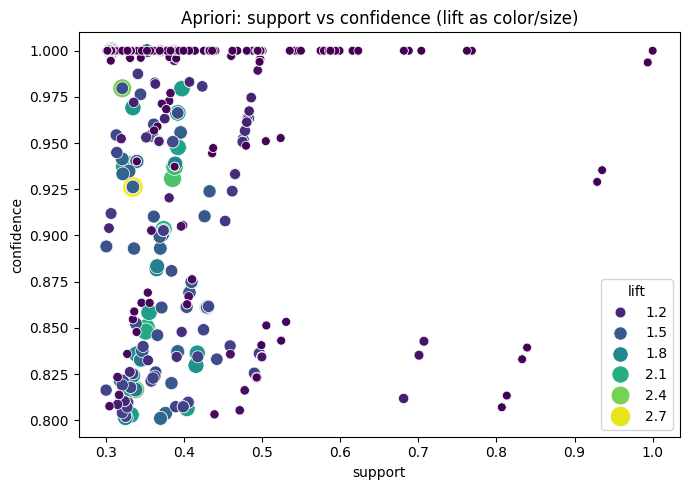

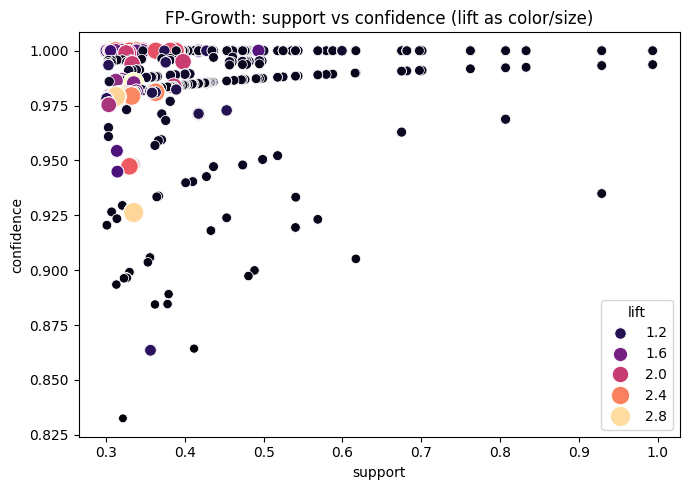

C:\Users\Ahmed Fahmy\AppData\Local\Temp\ipykernel_24376\3490430090.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eclat_df.head(top_n), y='itemset', x='support', palette='crest')


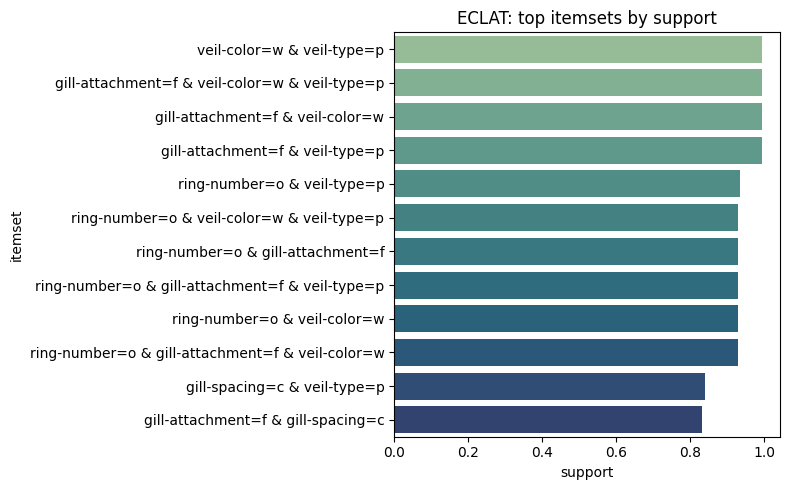

In [9]:
if not apriori_df.empty:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=apriori_df, x='support', y='confidence', hue='lift', size='lift', palette='viridis', sizes=(40, 220))
    plt.title('Apriori: support vs confidence (lift as color/size)')
    plt.tight_layout()
    plt.show()

if not fpg_df.empty:
    viz_fpg = fpg_df.dropna(subset=['support', 'confidence', 'lift']).copy()
    if not viz_fpg.empty:
        plt.figure(figsize=(7, 5))
        sns.scatterplot(data=viz_fpg, x='support', y='confidence', hue='lift', size='lift', palette='magma', sizes=(40, 220))
        plt.title('FP-Growth: support vs confidence (lift as color/size)')
        plt.tight_layout()
        plt.show()

if not eclat_df.empty:
    top_n = min(12, len(eclat_df))
    plt.figure(figsize=(8, 5))
    sns.barplot(data=eclat_df.head(top_n), y='itemset', x='support', palette='crest')
    plt.title('ECLAT: top itemsets by support')
    plt.tight_layout()
    plt.show()

,algorithm,available,patterns_or_itemsets,rules,avg_lift
0,Apriori,True,NaN,621.0,1.190554
1,FP-Growth,True,3616.0,3549.0,1.242590
2,ECLAT,True,750.0,NaN,NaN


C:\Users\Ahmed Fahmy\AppData\Local\Temp\ipykernel_24376\2133273143.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison.fillna(0), x='algorithm', y='patterns_or_itemsets', palette='Set2')


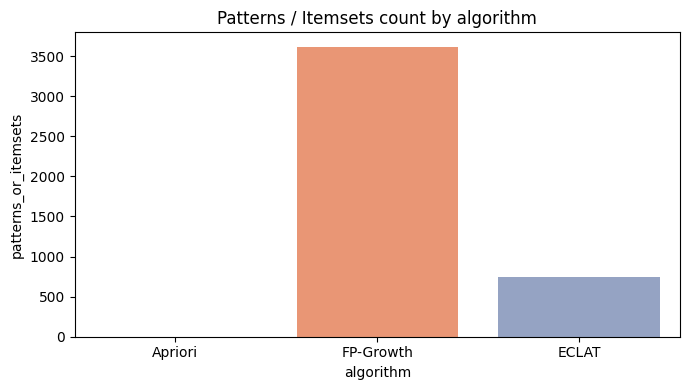

C:\Users\Ahmed Fahmy\AppData\Local\Temp\ipykernel_24376\2133273143.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison.fillna(0), x='algorithm', y='rules', palette='Set1')


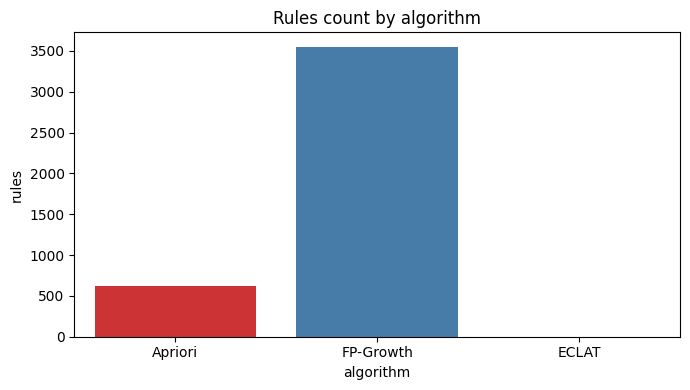

In [10]:
comparison = pd.DataFrame([
    {
        'algorithm': 'Apriori',
        'available': HAS_APYORI,
        'patterns_or_itemsets': np.nan,
        'rules': apriori_rules_count,
        'avg_lift': float(apriori_df['lift'].mean()) if not apriori_df.empty else np.nan
    },
    {
        'algorithm': 'FP-Growth',
        'available': HAS_PYFPGROWTH,
        'patterns_or_itemsets': fpg_patterns_count,
        'rules': fpg_rules_count,
        'avg_lift': float(fpg_df['lift'].mean()) if not fpg_df.empty else np.nan
    },
    {
        'algorithm': 'ECLAT',
        'available': HAS_PYECLAT,
        'patterns_or_itemsets': eclat_itemsets_count,
        'rules': np.nan,
        'avg_lift': np.nan
    }
])
display(comparison)

plt.figure(figsize=(7, 4))
sns.barplot(data=comparison.fillna(0), x='algorithm', y='patterns_or_itemsets', palette='Set2')
plt.title('Patterns / Itemsets count by algorithm')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
sns.barplot(data=comparison.fillna(0), x='algorithm', y='rules', palette='Set1')
plt.title('Rules count by algorithm')
plt.tight_layout()
plt.show()

## How To Use These Methods In This Project

- They are **not preprocessing** for classifiers; they are **pattern discovery** tools.
- Use them to discover combinations of mushroom features strongly linked to class labels.
- In your report, use these rules to explain *why* mushrooms are predicted edible/poisonous.
- Keep classification metrics as the main predictive result, and association rules as interpretability support.